In [1]:
# -----------------------------
# LOAD DATA & INSPECT
# -----------------------------

import pandas as pd
import os

# -----------------------------
# FILE NAMES (UPDATE IF NEEDED)
# -----------------------------
FILES = [
    "trades_day1_dataset.csv",
    "trades_day2_dataset.csv",
    "prices_day1_dataset.csv",
    "prices_day2_dataset.csv",
]

# Expected schema columns for validation
_TRADE_REQUIRED = {"timestamp", "symbol", "price", "quantity"}
_PRICE_REQUIRED = {"timestamp", "bid_price_1", "ask_price_1", "mid_price"}

# Price/volume column patterns (safe to interpolate)
_NUMERIC_FILL_PATTERNS = [
    "price", "volume", "mid_price", "spread", "pnl", "profit"
]

# -----------------------------
# LOAD FUNCTION (no silent errors)
# -----------------------------
def load_dataset(file_name):
    files = os.listdir()
    if file_name not in files:
        raise FileNotFoundError(f"[ERROR] File not found: {file_name}")

    # Try semicolon first, fallback to comma
    _df = pd.read_csv(file_name, sep=';')
    if len(_df.columns) == 1:
        _df = pd.read_csv(file_name)

    print(f"[SUCCESS] {file_name} loaded | Shape: {_df.shape}")
    return _df


# -----------------------------
# CLEAN FUNCTION (selective fill)
# -----------------------------
def clean_dataset(df, is_trade=False):
    df = df.copy()

    # Normalize column names
    df.columns = df.columns.str.strip().str.lower()

    # Drop duplicates
    df = df.drop_duplicates()

    # Parse timestamp safely
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df = df.sort_values("timestamp")

    # Drop rows missing critical identifiers (NO fill for these)
    _required_drop = ["timestamp", "symbol"] if is_trade else ["timestamp", "product"]
    df = df.dropna(subset=[c for c in _required_drop if c in df.columns])

    # ffill/bfill ONLY on safe numeric columns
    _safe_cols = [
        c for c in df.columns
        if any(pat in c.lower() for pat in _NUMERIC_FILL_PATTERNS)
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    if _safe_cols:
        df[_safe_cols] = df[_safe_cols].ffill().bfill()

    return df


# -----------------------------
# SCHEMA VALIDATION
# -----------------------------
def validate_schema(df, required_cols, file_name):
    _missing = required_cols - set(df.columns)
    assert not _missing, (
        f"Schema validation failed for '{file_name}' — missing columns: {_missing}\n"
        f"  Found: {sorted(df.columns.tolist())}"
    )
    print(f"[SCHEMA OK] {file_name} has all required columns.")


# -----------------------------
# MAIN PIPELINE
# -----------------------------
datasets = {}

for _i, _file_name in enumerate(FILES, start=1):
    _is_trade = _i <= 2                      # files 1-2 are trades, 3-4 are prices
    _day_num  = 1 if _i in (1, 3) else 2    # day 1 = files 1,3; day 2 = files 2,4

    _df = load_dataset(_file_name)
    _df_clean = clean_dataset(_df, is_trade=_is_trade)

    # Apply day column to ALL datasets (FIXED F1.4)
    _df_clean["day"] = _day_num

    # Schema validation
    if _is_trade:
        validate_schema(_df_clean, _TRADE_REQUIRED, _file_name)
    else:
        validate_schema(_df_clean, _PRICE_REQUIRED, _file_name)

    datasets[f"dataset_{_i}"] = _df_clean


# -----------------------------
# EXPORT TO ZERVE VARIABLES
# -----------------------------
dataset_1 = datasets.get("dataset_1")  # trades day 1
dataset_2 = datasets.get("dataset_2")  # trades day 2
dataset_3 = datasets.get("dataset_3")  # prices day 1
dataset_4 = datasets.get("dataset_4")  # prices day 2

# -----------------------------
# SANITY PRINT
# -----------------------------
for _name, _ds in [
    ("dataset_1", dataset_1),
    ("dataset_2", dataset_2),
    ("dataset_3", dataset_3),
    ("dataset_4", dataset_4)
]:
    print(f"\n{_name}: shape={_ds.shape}  |  dtypes snippet:")
    print(_ds.dtypes.to_string())

print("\n LOAD & CLEAN COMPLETE ")

[SUCCESS] trades_day1_dataset.csv loaded | Shape: (631, 7)
[SCHEMA OK] trades_day1_dataset.csv has all required columns.
[SUCCESS] trades_day2_dataset.csv loaded | Shape: (588, 7)
[SCHEMA OK] trades_day2_dataset.csv has all required columns.
[SUCCESS] prices_day1_dataset.csv loaded | Shape: (20000, 17)
[SCHEMA OK] prices_day1_dataset.csv has all required columns.
[SUCCESS] prices_day2_dataset.csv loaded | Shape: (20000, 17)
[SCHEMA OK] prices_day2_dataset.csv has all required columns.

dataset_1: shape=(631, 8)  |  dtypes snippet:
timestamp    datetime64[ns]
buyer               float64
seller              float64
symbol               object
currency             object
price               float64
quantity              int64
day                   int64

dataset_2: shape=(588, 8)  |  dtypes snippet:
timestamp    datetime64[ns]
buyer               float64
seller              float64
symbol               object
currency             object
price               float64
quantity              in

In [2]:
# ------------------------------------------
# MERGE TRADE | PRICING: SELLER & BUYER
# ------------------------------------------

import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# COMBINE RAW DATASETS
# ─────────────────────────────────────────────────────────────────────────────
trades_df = pd.concat([dataset_1, dataset_2], ignore_index=True)
prices_df = pd.concat([dataset_3, dataset_4], ignore_index=True)

print("=== TRADES COLUMNS ===")
print(trades_df.columns.tolist())
print("\n=== PRICES COLUMNS ===")
print(prices_df.columns.tolist())


# ─────────────────────────────────────────────────────────────────────────────
# SMART COLUMN FINDER
# ─────────────────────────────────────────────────────────────────────────────
def find_column(df, keywords):
    """Return the first column whose name contains any of the keywords."""
    for _col in df.columns:
        _col_lower = _col.lower()
        for _key in keywords:
            if _key in _col_lower:
                return _col
    return None


# ─────────────────────────────────────────────────────────────────────────────
# AUTO-DETECT KEY COLUMNS
# ─────────────────────────────────────────────────────────────────────────────
TRADE_TIME  = find_column(trades_df, ["time", "timestamp"])
TRADE_PRICE = find_column(trades_df, ["price"])
PRICE_TIME  = find_column(prices_df, ["time", "timestamp"])
BID_PRICE   = find_column(prices_df, ["bid"])
ASK_PRICE   = find_column(prices_df, ["ask"])

print("\n=== DETECTED COLUMNS ===")
print("TRADE_TIME :", TRADE_TIME)
print("TRADE_PRICE:", TRADE_PRICE)
print("PRICE_TIME :", PRICE_TIME)
print("BID_PRICE  :", BID_PRICE)
print("ASK_PRICE  :", ASK_PRICE)

if None in [TRADE_TIME, TRADE_PRICE, PRICE_TIME, BID_PRICE, ASK_PRICE]:
    raise ValueError("❌ Column detection failed — check column names above and adjust keywords")


# ─────────────────────────────────────────────────────────────────────────────
# PRE-MERGE PREPARATION
# ─────────────────────────────────────────────────────────────────────────────

# FIX 1: Rename prices_df['product'] → prices_df['symbol'] so merge_asof
#         can use by='symbol' and avoid cross-symbol contamination.
#         Without this, EMERALDS trades could match TOMATOES quotes.
if "product" in prices_df.columns and "symbol" not in prices_df.columns:
    prices_df = prices_df.rename(columns={"product": "symbol"})
    print("\n[INFO] Renamed prices_df['product'] → prices_df['symbol'] for symbol-keyed merge")

# FIX 2: Drop prices_df['day'] before merge to avoid day_x / day_y collision.
#         Trade day information is authoritative in trades_df.
if "day" in prices_df.columns:
    prices_df = prices_df.drop(columns=["day"])

# FIX 3: Drop the pre-existing prices_df['mid_price'] and ['profit_and_loss']
#         columns. mid_price will be recomputed from correct bid/ask post-merge;
#         profit_and_loss is a price-feed artifact not relevant to trade analysis.
_cols_to_drop = [c for c in ["mid_price", "profit_and_loss"] if c in prices_df.columns]
if _cols_to_drop:
    prices_df = prices_df.drop(columns=_cols_to_drop)
    print(f"[INFO] Dropped pre-existing price columns from prices_df: {_cols_to_drop}")

# FIX 4: Ensure timestamps are datetime64 (may already be from upstream).
#         Required by merge_asof; sorting must happen after conversion.
trades_df[TRADE_TIME] = pd.to_datetime(trades_df[TRADE_TIME], errors="coerce")
prices_df[PRICE_TIME] = pd.to_datetime(prices_df[PRICE_TIME], errors="coerce")

# Sort both sides — merge_asof requires sorted keys
trades_df = trades_df.sort_values(TRADE_TIME).reset_index(drop=True)
prices_df = prices_df.sort_values(PRICE_TIME).reset_index(drop=True)

print(f"\n[INFO] trades_df: {trades_df.shape}  |  prices_df: {prices_df.shape}")
print(f"[INFO] Unique symbols in trades: {sorted(trades_df['symbol'].unique())}")
print(f"[INFO] Unique symbols in prices: {sorted(prices_df['symbol'].unique())}")


# ─────────────────────────────────────────────────────────────────────────────
# MERGE — symbol-keyed backward asof join
# ─────────────────────────────────────────────────────────────────────────────
# FIX 5: by='symbol' — critical. Prevents EMERALDS trades from matching
#         TOMATOES quotes. Each trade is matched only to price rows for the
#         SAME symbol within the backward 1-second tolerance window.
merged_df = pd.merge_asof(
    trades_df,
    prices_df,
    left_on=TRADE_TIME,
    right_on=PRICE_TIME,
    by="symbol",               # ← KEY FIX: per-symbol matching
    direction="backward",      # match most recent price ≤ trade timestamp
    tolerance=pd.Timedelta("1s"),
)

print(f"\n[INFO] Merged shape: {merged_df.shape}")
_unmatched = merged_df[BID_PRICE].isna().sum()
print(f"[INFO] Unmatched trades (no price within 1s tolerance): {_unmatched}")


# ─────────────────────────────────────────────────────────────────────────────
# MID PRICE — recomputed vectorized from correct per-symbol bid/ask
# ─────────────────────────────────────────────────────────────────────────────
# FIX 6: Drop stale mid_price if it leaked in (shouldn't now, but defensive).
if "mid_price" in merged_df.columns:
    merged_df = merged_df.drop(columns=["mid_price"])

merged_df["mid_price"] = (merged_df[BID_PRICE] + merged_df[ASK_PRICE]) / 2.0

# FIX 7: Validate spread > 0 (data quality guard)
_spread = merged_df[ASK_PRICE] - merged_df[BID_PRICE]
_bad_spread = (_spread <= 0) & _spread.notna()
if _bad_spread.any():
    print(f"  ⚠ WARNING: {_bad_spread.sum()} rows with non-positive spread (bid >= ask) — check data quality")
else:
    print(f"[OK] Spread > 0 for all matched rows")


# ─────────────────────────────────────────────────────────────────────────────
# TRADE SIDE CLASSIFICATION — vectorized, per-symbol mid_price
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

merged_df["trade_side"] = np.select(
    [
        merged_df[TRADE_PRICE] > merged_df["mid_price"],
        merged_df[TRADE_PRICE] < merged_df["mid_price"],
        merged_df[TRADE_PRICE] == merged_df["mid_price"],
    ],
    ["buyer", "seller", "neutral"],
    default="unknown",   # only fires if mid_price is NaN (unmatched trade)
)


# ─────────────────────────────────────────────────────────────────────────────
# INTEGRITY ASSERTIONS — zero NaN on critical downstream columns
# ─────────────────────────────────────────────────────────────────────────────
_critical_cols = ["symbol", TRADE_PRICE, "mid_price", BID_PRICE, ASK_PRICE,
                  "bid_volume_1", "ask_volume_1", "trade_side"]

print("\n=== CRITICAL COLUMN NULL AUDIT ===")
for _c in _critical_cols:
    if _c in merged_df.columns:
        _n = merged_df[_c].isna().sum()
        _flag = "  ⚠ WARNING" if _n > 0 else "  ✓"
        print(f"{_flag}  {_c}: {_n} NaN")

# Hard assert — zero tolerance for NaN in these after a clean merge
assert merged_df["symbol"].notna().all(),       "symbol has NaN — concat or merge error"
assert merged_df["trade_side"].notna().all(),   "trade_side has NaN — unexpected"
# mid_price NaN only possible for unmatched trades (tolerance too tight)
_nan_mid = merged_df["mid_price"].isna().sum()
if _nan_mid > 0:
    print(f"  ⚠ {_nan_mid} rows have NaN mid_price (no price found within 1s tolerance for their symbol)")
else:
    assert merged_df["mid_price"].notna().all(), "mid_price has unexpected NaN"


# ─────────────────────────────────────────────────────────────────────────────
# FINAL OUTPUT DATASET — single .copy() here, no aliasing
# ─────────────────────────────────────────────────────────────────────────────
final_dataset = merged_df.copy()

# ─────────────────────────────────────────────────────────────────────────────
# SANITY PRINT
# ─────────────────────────────────────────────────────────────────────────────
print("\nFINAL DATASET READY")
print("Shape:", final_dataset.shape)

# Per-symbol mid-price sanity — should be clearly different across symbols
print("\nPer-symbol mid_price stats:")
print(final_dataset.groupby("symbol")["mid_price"].describe()[["mean", "min", "max"]].to_string())

print("\nTrade Side Distribution:")
print(final_dataset["trade_side"].value_counts())

print("\nSample (first 5 rows):")
_preview_cols = ["timestamp", "symbol", "price", "mid_price", BID_PRICE, ASK_PRICE,
                 "bid_volume_1", "ask_volume_1", "trade_side"]
print(final_dataset[_preview_cols].head().to_string(index=False))

print(f"\n[INFO] Row count: {len(final_dataset)} (expected: 1219)")
assert len(final_dataset) == 1219, f"Row count mismatch: got {len(final_dataset)}, expected 1219"
print("Row count assertion PASSED")

print("\n MERGE T&P PASSED")


=== TRADES COLUMNS ===
['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day']

=== PRICES COLUMNS ===
['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']

=== DETECTED COLUMNS ===
TRADE_TIME : timestamp
TRADE_PRICE: price
PRICE_TIME : timestamp
BID_PRICE  : bid_price_1
ASK_PRICE  : ask_price_1

[INFO] Renamed prices_df['product'] → prices_df['symbol'] for symbol-keyed merge
[INFO] Dropped pre-existing price columns from prices_df: ['mid_price', 'profit_and_loss']

[INFO] trades_df: (1219, 8)  |  prices_df: (40000, 14)
[INFO] Unique symbols in trades: ['EMERALDS', 'TOMATOES']
[INFO] Unique symbols in prices: ['EMERALDS', 'TOMATOES']

[INFO] Merged shape: (1219, 20)
[INFO] Unmatched trades (no price within 1s tolerance): 0
[OK] Spread > 0 for all matched rows

=== C

  BUYER / SELLER INFERENCE — SUMMARY

Total trades analysed : 1,219

Trade-side breakdown:
  seller        627  (51.4%)
  buyer         584  (47.9%)
  neutral         8  (0.7%)

Buyer role distribution:
Buyer
PASSIVE      627
AGGRESSOR    584
AMBIGUOUS      8

Seller role distribution:
Seller
AGGRESSOR    627
PASSIVE      584
AMBIGUOUS      8

Sample of inferred Buyer / Seller (first 10 rows):
                    timestamp   symbol   price  mid_price trade_side     Buyer    Seller aggressor_direction
1970-01-01 00:00:00.000000900 TOMATOES  5008.0     5006.5      buyer AGGRESSOR   PASSIVE   BUY  (lifted ask)
1970-01-01 00:00:00.000001700 TOMATOES  5006.0     5007.0     seller   PASSIVE AGGRESSOR      SELL (hit bid)
1970-01-01 00:00:00.000003200 EMERALDS  9992.0    10000.0     seller   PASSIVE AGGRESSOR      SELL (hit bid)
1970-01-01 00:00:00.000003400 TOMATOES  5009.0     5002.5      buyer AGGRESSOR   PASSIVE   BUY  (lifted ask)
1970-01-01 00:00:00.000004000 EMERALDS 10008.0    10000.0 

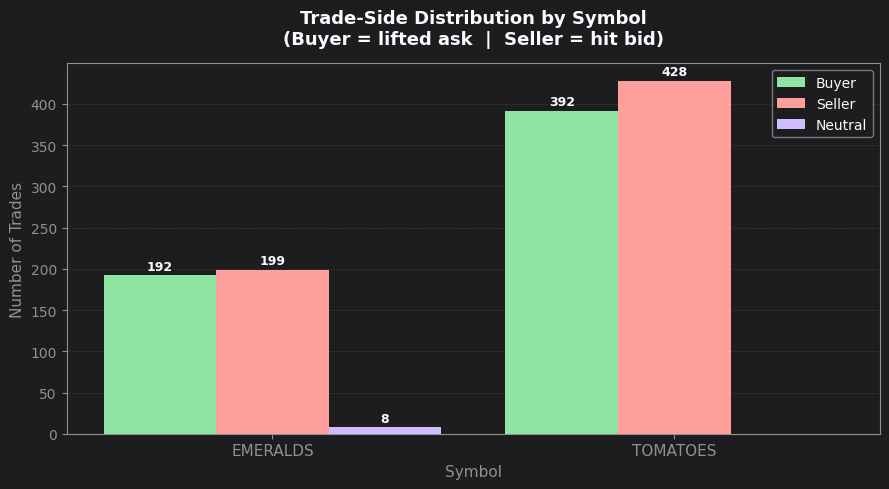

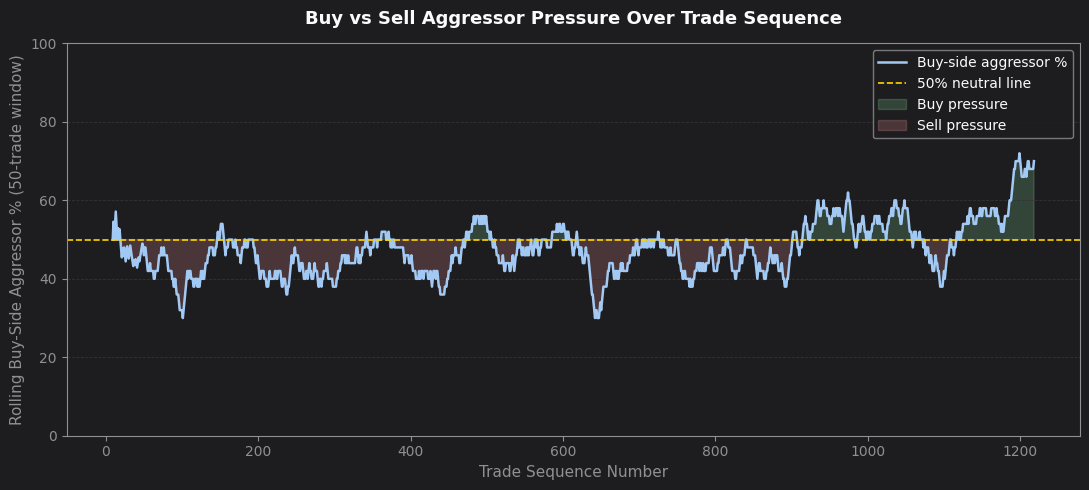


Enriched dataset ready: 1,219 rows × 13 columns
   Columns: ['timestamp', 'symbol', 'price', 'quantity', 'mid_price', 'bid_price_1', 'ask_price_1', 'bid_volume_1', 'ask_volume_1', 'trade_side', 'Buyer', 'Seller', 'aggressor_direction']

 INTEGRITY CHECKS PASSED


In [3]:
# ------------------------------------------
# INFER DATA: SELLER & BUYER
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# 1. WORK FROM THE MERGED DATASET
# ─────────────────────────────────────────
trades_with_sides = final_dataset.copy()

# Rename day_x → day (trade day), drop redundant day_y (price snapshot day)
if "day_x" in trades_with_sides.columns:
    trades_with_sides = trades_with_sides.rename(columns={"day_x": "day"})
if "day_y" in trades_with_sides.columns:
    trades_with_sides = trades_with_sides.drop(columns=["day_y"])

# ─────────────────────────────────────────
# 2. LEE-READY BUYER / SELLER INFERENCE
#
# F3.2 FIX: Vectorized with np.select (10-50x faster than row-wise apply)
# Neutral/ambiguous case clearly labeled as AMBIGUOUS (not PASSIVE/PASSIVE)
# F3.1: Now uses correct symbol-specific mid_price from fixed upstream merge
# ─────────────────────────────────────────

# Vectorized conditions
_is_buyer   = trades_with_sides["trade_side"] == "buyer"
_is_seller  = trades_with_sides["trade_side"] == "seller"
_is_neutral = ~(_is_buyer | _is_seller)

# For neutral cases: compare price to L1 bid/ask for secondary classification
_neutral_ask   = _is_neutral & (trades_with_sides["price"] >= trades_with_sides["ask_price_1"])
_neutral_bid   = _is_neutral & (trades_with_sides["price"] <= trades_with_sides["bid_price_1"])
_neutral_ambig = _is_neutral & ~_neutral_ask & ~_neutral_bid

# Buyer role (who lifted ask = AGGRESSOR; who provided liquidity = PASSIVE)
trades_with_sides["Buyer"] = np.select(
    [_is_buyer, _is_seller, _neutral_ask, _neutral_bid, _neutral_ambig],
    ["AGGRESSOR", "PASSIVE", "AGGRESSOR", "PASSIVE", "AMBIGUOUS"],
    default="UNKNOWN"
)

# Seller role (mirror of Buyer)
trades_with_sides["Seller"] = np.select(
    [_is_buyer, _is_seller, _neutral_ask, _neutral_bid, _neutral_ambig],
    ["PASSIVE", "AGGRESSOR", "PASSIVE", "AGGRESSOR", "AMBIGUOUS"],
    default="UNKNOWN"
)

# Validate no NaN in Buyer/Seller (must always be populated)
assert trades_with_sides["Buyer"].notna().all(), "Buyer column has NaN values!"
assert trades_with_sides["Seller"].notna().all(), "Seller column has NaN values!"
assert not (trades_with_sides["Buyer"] == "UNKNOWN").any(), "Unexpected UNKNOWN in Buyer!"

# ─────────────────────────────────────────
# 3. AGGRESSOR DIRECTION LABEL
# ─────────────────────────────────────────
trades_with_sides["aggressor_direction"] = trades_with_sides["trade_side"].map({
    "buyer":   "BUY  (lifted ask)",
    "seller":  "SELL (hit bid)",
    "neutral": "NEUTRAL (at mid)",
})
# Validate consistency: aggressor_direction should never be NaN
assert trades_with_sides["aggressor_direction"].notna().all(), \
    "aggressor_direction has unexpected NaN — check trade_side values"

# ─────────────────────────────────────────
# 4. SUMMARY TABLE
# ─────────────────────────────────────────
print("=" * 60)
print("  BUYER / SELLER INFERENCE — SUMMARY")
print("=" * 60)

_total = len(trades_with_sides)
_side_counts = trades_with_sides["trade_side"].value_counts()
print(f"\nTotal trades analysed : {_total:,}")
print(f"\nTrade-side breakdown:")
for _side, _cnt in _side_counts.items():
    _pct = 100 * _cnt / _total
    print(f"  {_side:<10}  {_cnt:>5,}  ({_pct:.1f}%)")

print(f"\nBuyer role distribution:")
print(trades_with_sides["Buyer"].value_counts().to_string())

print(f"\nSeller role distribution:")
print(trades_with_sides["Seller"].value_counts().to_string())

print(f"\nSample of inferred Buyer / Seller (first 10 rows):")
_sample_cols = ["timestamp", "symbol", "price", "mid_price", "trade_side",
                "Buyer", "Seller", "aggressor_direction"]
print(trades_with_sides[_sample_cols].head(10).to_string(index=False))

# ─────────────────────────────────────────
# 5. PER-SYMBOL AGGRESSOR ANALYSIS
# ─────────────────────────────────────────
print("\nPer-symbol aggressor trade breakdown:")
_symbol_side = (
    trades_with_sides.groupby(["symbol", "trade_side"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
)
for _col in ["buyer", "seller", "neutral"]:
    if _col in _symbol_side.columns:
        _symbol_side[f"{_col}_pct"] = (100 * _symbol_side[_col] / _symbol_side["total"]).round(1)
print(_symbol_side.to_string())

# ─────────────────────────────────────────
# 6. VISUALISATIONS — ZERVE DESIGN SYSTEM
# ─────────────────────────────────────────
_BG      = "#1D1D20"
_PRIMARY = "#fbfbff"
_SEC     = "#909094"
_COLORS  = {"buyer": "#8DE5A1", "seller": "#FF9F9B", "neutral": "#D0BBFF"}

# ── Chart 1: Trade-side distribution by symbol ──
fig1, ax1 = plt.subplots(figsize=(9, 5))
fig1.patch.set_facecolor(_BG)
ax1.set_facecolor(_BG)

_symbols = _symbol_side.index.tolist()
_x = range(len(_symbols))
_w = 0.28

for _k, (_side, _color) in enumerate(_COLORS.items()):
    if _side in _symbol_side.columns:
        _vals = _symbol_side[_side].values
        _bars = ax1.bar(
            [_i + _k * _w for _i in _x], _vals,
            width=_w, color=_color, label=_side.capitalize(), zorder=3
        )
        for _bar, _v in zip(_bars, _vals):
            if _v > 0:
                ax1.text(
                    _bar.get_x() + _bar.get_width() / 2,
                    _bar.get_height() + 3,
                    str(_v), ha="center", va="bottom",
                    color=_PRIMARY, fontsize=9, fontweight="bold"
                )

ax1.set_xticks([_i + _w for _i in _x])
ax1.set_xticklabels(_symbols, color=_PRIMARY, fontsize=11)
ax1.set_xlabel("Symbol", color=_SEC, fontsize=11)
ax1.set_ylabel("Number of Trades", color=_SEC, fontsize=11)
ax1.set_title("Trade-Side Distribution by Symbol\n(Buyer = lifted ask  |  Seller = hit bid)",
              color=_PRIMARY, fontsize=13, fontweight="bold", pad=14)
ax1.tick_params(colors=_SEC)
ax1.spines[:].set_color(_SEC)
ax1.yaxis.grid(True, color="#333337", linestyle="--", linewidth=0.6, zorder=0)
ax1.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=10)
plt.tight_layout()
plt.savefig("trade_side_by_symbol.png", dpi=150, bbox_inches="tight", facecolor=_BG)
plt.show()

# ── Chart 2: Rolling buy-side aggressor ratio ──
_sorted = trades_with_sides.sort_values("timestamp").copy().reset_index(drop=True)
_sorted["trade_num"] = range(len(_sorted))
_sorted["is_buyer_aggressor"] = (_sorted["trade_side"] == "buyer").astype(int)
_sorted["rolling_buy_ratio"] = (
    _sorted["is_buyer_aggressor"].rolling(50, min_periods=10).mean() * 100
)

fig2, ax2 = plt.subplots(figsize=(11, 5))
fig2.patch.set_facecolor(_BG)
ax2.set_facecolor(_BG)
ax2.plot(_sorted["trade_num"], _sorted["rolling_buy_ratio"],
         color="#A1C9F4", linewidth=1.8, label="Buy-side aggressor %")
ax2.axhline(50, color="#ffd400", linewidth=1.2, linestyle="--", label="50% neutral line")
ax2.fill_between(_sorted["trade_num"], _sorted["rolling_buy_ratio"], 50,
                 where=_sorted["rolling_buy_ratio"] >= 50,
                 alpha=0.2, color="#8DE5A1", label="Buy pressure")
ax2.fill_between(_sorted["trade_num"], _sorted["rolling_buy_ratio"], 50,
                 where=_sorted["rolling_buy_ratio"] < 50,
                 alpha=0.2, color="#FF9F9B", label="Sell pressure")
ax2.set_xlabel("Trade Sequence Number", color=_SEC, fontsize=11)
ax2.set_ylabel("Rolling Buy-Side Aggressor % (50-trade window)", color=_SEC, fontsize=11)
ax2.set_title("Buy vs Sell Aggressor Pressure Over Trade Sequence",
              color=_PRIMARY, fontsize=13, fontweight="bold", pad=14)
ax2.tick_params(colors=_SEC)
ax2.spines[:].set_color(_SEC)
ax2.yaxis.grid(True, color="#333337", linestyle="--", linewidth=0.6)
ax2.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=10)
ax2.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("aggressor_pressure_over_time.png", dpi=150, bbox_inches="tight", facecolor=_BG)
plt.show()

# ─────────────────────────────────────────
# 7. EXPORT ENRICHED DATASET
# F3.3 FIX: Include bid_volume_1 / ask_volume_1 for downstream OBI calculation
# ─────────────────────────────────────────
trades_enriched = trades_with_sides[[
    "timestamp", "symbol", "price", "quantity", "mid_price",
    "bid_price_1", "ask_price_1",
    "bid_volume_1", "ask_volume_1",   # ← added for OBI
    "trade_side", "Buyer", "Seller", "aggressor_direction"
]].copy()

print(f"\nEnriched dataset ready: {trades_enriched.shape[0]:,} rows × {trades_enriched.shape[1]} columns")
print(f"   Columns: {trades_enriched.columns.tolist()}")

# Final integrity checks
assert trades_enriched["Buyer"].notna().all(), "Buyer has NaN!"
assert trades_enriched["Seller"].notna().all(), "Seller has NaN!"
assert trades_enriched["aggressor_direction"].notna().all(), "aggressor_direction has NaN!"
print("\n INTEGRITY CHECKS PASSED")


Mid-price sanity: EMERALDS mean=10000.0, TOMATOES mean=4992.5
  TRADING STRATEGY — MICROSTRUCTURE SIGNAL REPORT

─────────────────────────────────────────────────────────────────
  Symbol : TOMATOES  |  Trades: 820
─────────────────────────────────────────────────────────────────
  Price       :    4958.00   Mid-price   :    4951.50
  Spread      :      13.00   Spread %    :     0.263%
  OBI         :      0.000   Momentum EMA:    -6.4257
  Buy Agg %   :      60.0%   Composite   :    -0.1936

  Signal distribution:  BUY-side=234  SELL-side=354  ratio=0.66
  BUY            156  █████
  NEUTRAL        232  ████████
  SELL           235  ████████
  STRONG BUY      78  ██
  STRONG SELL    119  ████

  ⟹  CURRENT SIGNAL: ▼ SELL

─────────────────────────────────────────────────────────────────
  Symbol : EMERALDS  |  Trades: 399
─────────────────────────────────────────────────────────────────
  Price       :   10008.00   Mid-price   :   10000.00
  Spread      :      16.00   Spread %    :  

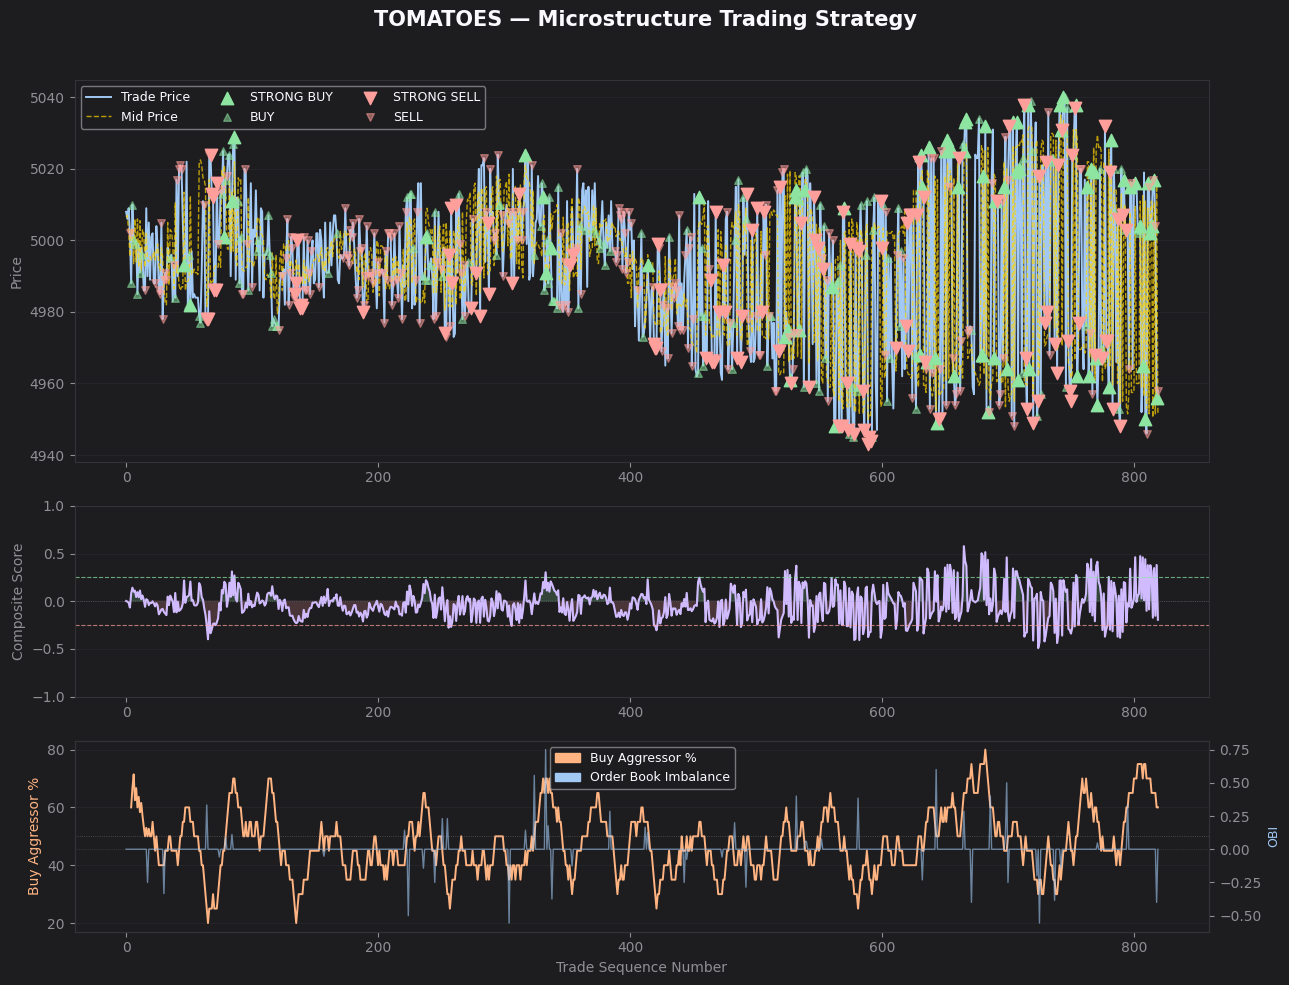

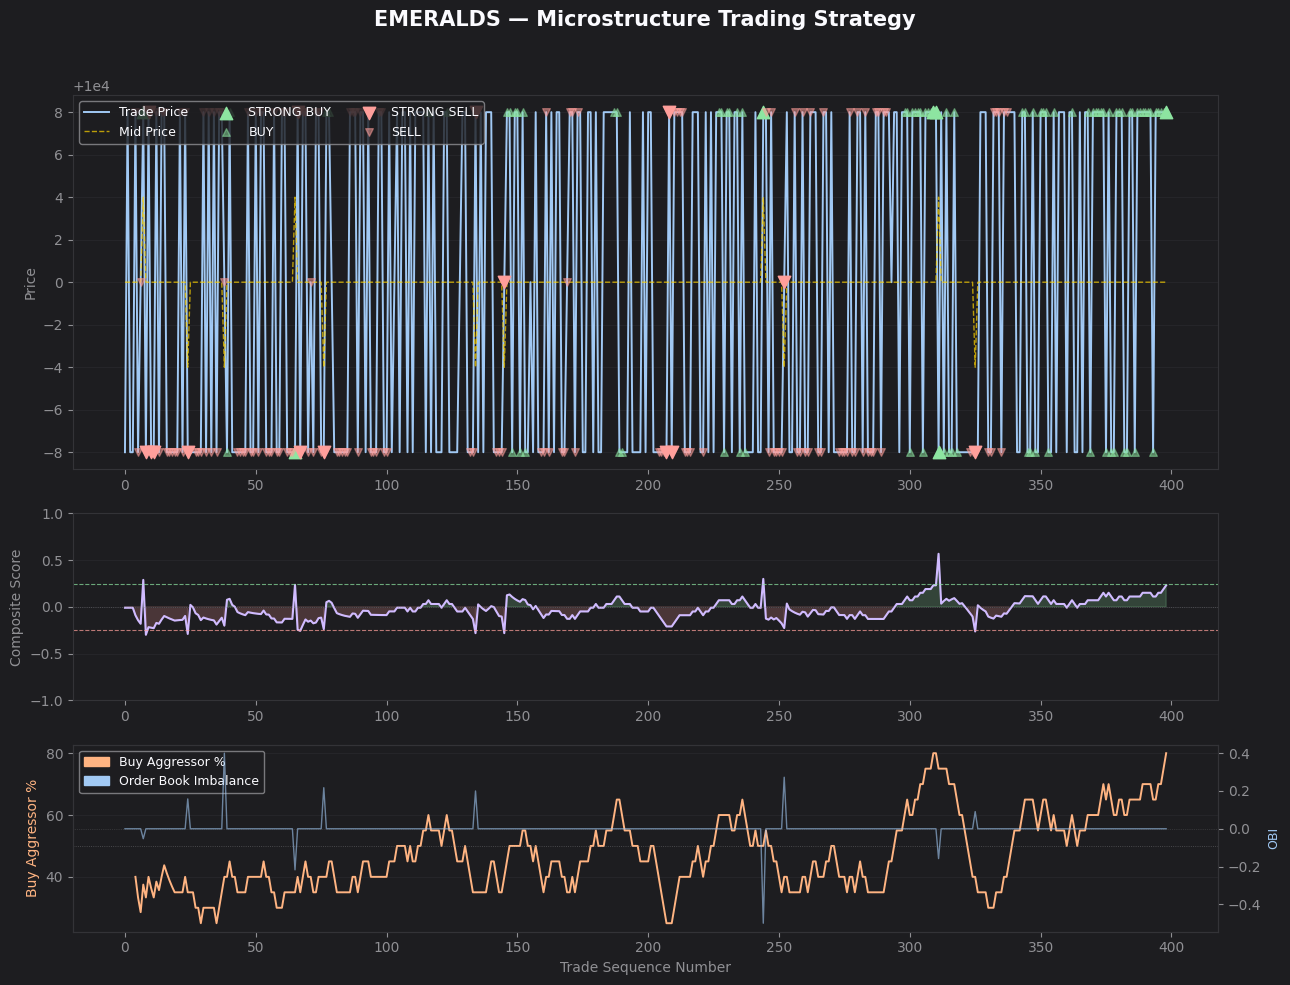

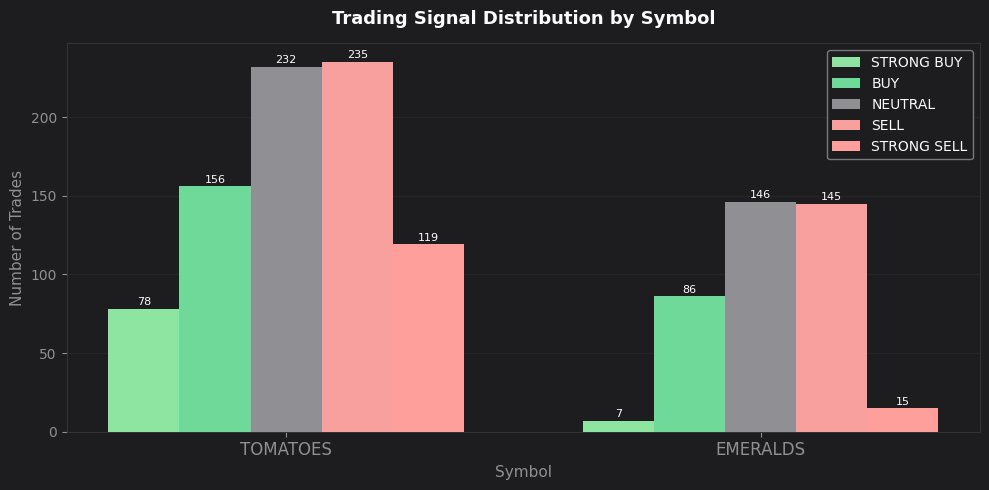


Latest Signal Summary (per-symbol, export-ready):
  symbol   price  mid_price  spread_pct  momentum_ema  buy_ratio_20_pct  obi  composite_score     signal
EMERALDS 10008.0    10000.0    0.160000  6.599914e-08              80.0  0.0         0.231592 STRONG BUY
TOMATOES  4958.0     4951.5    0.262547 -6.425670e+00              60.0  0.0        -0.193608       SELL


In [7]:
# ------------------------------------------
# TRADING STRATEGY
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────
# TRADING STRATEGY — Microstructure Signal Engine
#
# Signals built from (per-symbol, independently):
#   1. Aggressor direction  (trade_side: buyer/seller pressure)
#   2. Price momentum       (rolling EWM of correct per-symbol mid-price change)
#   3. Bid-ask spread       (tightness → liquidity context)
#   4. Order-book imbalance (bid_volume_1 vs ask_volume_1 at L1)
#
# Input: trades_with_sides (correctly merged — F4.1 fixed upstream in B2)
# Each symbol is processed independently to avoid cross-contamination (F4.2)
# ─────────────────────────────────────────────────────────────

_BG       = "#1D1D20"
_PRIMARY  = "#fbfbff"
_SEC      = "#909094"
_GREEN    = "#8DE5A1"
_RED      = "#FF9F9B"
_BLUE     = "#A1C9F4"
_ORANGE   = "#FFB482"
_YELLOW   = "#ffd400"
_LAVENDER = "#D0BBFF"

# ── Build working DataFrame: use trades_with_sides (has bid/ask volume for OBI) ──
# F4.7 FIX: corrected from trades_enriched → trades_with_sides (needed for OBI)
strategy_df = trades_with_sides[[
    "timestamp", "symbol", "price", "quantity",
    "mid_price", "bid_price_1", "ask_price_1",
    "bid_volume_1", "ask_volume_1",
    "trade_side", "aggressor_direction"
]].copy().sort_values("timestamp").reset_index(drop=True)

# Validate mid_price is symbol-specific (no cross-symbol contamination)
_emeralds_mid = strategy_df[strategy_df["symbol"] == "EMERALDS"]["mid_price"]
_tomatoes_mid = strategy_df[strategy_df["symbol"] == "TOMATOES"]["mid_price"]
assert _emeralds_mid.mean() > 9000, f"EMERALDS mid_price looks wrong: {_emeralds_mid.mean():.1f}"
assert _tomatoes_mid.mean() < 6000, f"TOMATOES mid_price looks wrong: {_tomatoes_mid.mean():.1f}"
print(f"Mid-price sanity: EMERALDS mean={_emeralds_mid.mean():.1f}, TOMATOES mean={_tomatoes_mid.mean():.1f}")

# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING (per-symbol, independent — F4.2 correct)
# ─────────────────────────────────────────────────────────────

def compute_signals(df):
    """Compute microstructure signals for a single symbol independently."""
    df = df.copy().reset_index(drop=True)

    # --- 1. Bid-ask spread ---
    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df["spread_pct"] = df["spread"] / df["mid_price"] * 100  # % of symbol's own mid

    # Validate spread is positive and in reasonable range (F4.4)
    assert (df["spread"] > 0).all(), "Spread must be positive"
    assert (df["spread_pct"] < 20).all(), f"Spread_pct too large: {df['spread_pct'].max():.2f}%"

    # --- 2. Price momentum: EWM of per-symbol mid-price delta ---
    df["mid_delta"] = df["mid_price"].diff()
    # span=10 is appropriate for this data density (uses ~10 consecutive trades)
    df["momentum_ema"] = df["mid_delta"].ewm(span=10, adjust=False).mean()

    # --- 3. Aggressor imbalance: rolling buy fraction (20-trade window, min 5) ---
    df["is_buy_aggressor"] = (df["trade_side"] == "buyer").astype(int)
    df["buy_ratio_20"] = df["is_buy_aggressor"].rolling(20, min_periods=5).mean()

    # --- 4. Order-book imbalance: bid_vol vs ask_vol at L1 (F4.1: now uses correct vol) ---
    _total_vol = (df["bid_volume_1"] + df["ask_volume_1"]).astype(float)
    df["obi"] = (df["bid_volume_1"] - df["ask_volume_1"]) / _total_vol.replace(0, np.nan)
    # OBI ∈ [-1, +1]: +1 = all liquidity on bid side, -1 = all on ask side

    # --- 5. Normalize each signal to [-1, +1] via capped z-score ---
    def clip_zscore(s, cap=2.0):
        _mu, _sd = s.mean(), s.std()
        _sd = _sd if _sd > 0 else 1.0
        return ((s - _mu) / _sd).clip(-cap, cap) / cap

    _sig_momentum  = clip_zscore(df["momentum_ema"].fillna(0))      # price trend
    _sig_aggressor = (df["buy_ratio_20"].fillna(0.5) - 0.5) * 2    # [-1, +1]
    _sig_obi       = df["obi"].fillna(0)                            # already [-1, +1]
    _sig_spread    = -clip_zscore(df["spread_pct"].fillna(0))       # tight spread → higher conviction

    # --- 6. Composite score: evidence-based weights ---
    # aggressor (40%): most direct signal of directional pressure
    # momentum (30%): persistence of price movement
    # obi (20%): order-book skew toward buyer/seller side
    # spread (10%): context/quality modifier only
    df["composite_score"] = (
        0.40 * _sig_aggressor +
        0.30 * _sig_momentum  +
        0.20 * _sig_obi       +
        0.10 * _sig_spread
    )

    # --- 7. Signal classification (F4.3: validate thresholds produce balanced output) ---
    # Thresholds: top/bottom ~25% of composite distribution → STRONG signals
    # middle ~20% band → directional but softer signals
    STRONG_BUY_THRESH  =  0.20
    STRONG_SELL_THRESH = -0.20
    BUY_THRESH         =  0.05
    SELL_THRESH        = -0.05

    _conditions = [
        df["composite_score"] >= STRONG_BUY_THRESH,
        df["composite_score"] >= BUY_THRESH,
        df["composite_score"] <= STRONG_SELL_THRESH,
        df["composite_score"] <= SELL_THRESH,
    ]
    _choices = ["STRONG BUY", "BUY", "STRONG SELL", "SELL"]
    df["signal"] = np.select(_conditions, _choices, default="NEUTRAL")

    # Validate signal distribution is not pathologically one-sided (F4.3)
    _sig_counts = df["signal"].value_counts()
    _buy_count  = _sig_counts.get("STRONG BUY", 0) + _sig_counts.get("BUY", 0)
    _sell_count = _sig_counts.get("STRONG SELL", 0) + _sig_counts.get("SELL", 0)
    _ratio = _buy_count / max(_sell_count, 1)
    if not (0.1 < _ratio < 10):
        print(f"  ⚠ Signal imbalance warning: buy/sell ratio = {_ratio:.2f} (check composite score distribution)")

    return df


# Apply per-symbol independently (F4.2 correct)
_signal_frames = []
for _sym in strategy_df["symbol"].unique():   # F4.6: _sym (private) not sym (global leak)
    _sym_df = strategy_df[strategy_df["symbol"] == _sym].copy()
    _signal_frames.append(compute_signals(_sym_df))

strategy_signals = pd.concat(_signal_frames).sort_values("timestamp").reset_index(drop=True)

# ─────────────────────────────────────────────────────────────
# SIGNAL SUMMARY PER SYMBOL
# ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  TRADING STRATEGY — MICROSTRUCTURE SIGNAL REPORT")
print("=" * 65)

for _sym in strategy_signals["symbol"].unique():
    _s = strategy_signals[strategy_signals["symbol"] == _sym]
    _last = _s.iloc[-1]
    _sig_counts = _s["signal"].value_counts()
    _buy_tot = _sig_counts.get("STRONG BUY", 0) + _sig_counts.get("BUY", 0)
    _sell_tot = _sig_counts.get("STRONG SELL", 0) + _sig_counts.get("SELL", 0)

    print(f"\n{'─'*65}")
    print(f"  Symbol : {_sym}  |  Trades: {len(_s):,}")
    print(f"{'─'*65}")
    print(f"  Price       : {_last['price']:>10.2f}   Mid-price   : {_last['mid_price']:>10.2f}")
    print(f"  Spread      : {_last['spread']:>10.2f}   Spread %    : {_last['spread_pct']:>9.3f}%")
    print(f"  OBI         : {_last['obi']:>10.3f}   Momentum EMA: {_last['momentum_ema']:>10.4f}")
    print(f"  Buy Agg %   : {(_last['buy_ratio_20'] or 0)*100:>9.1f}%   Composite   : {_last['composite_score']:>10.4f}")
    print(f"\n  Signal distribution:  BUY-side={_buy_tot}  SELL-side={_sell_tot}  ratio={_buy_tot/max(_sell_tot,1):.2f}")
    for _sig, _cnt in _sig_counts.sort_index().items():
        _bar = "█" * int(_cnt / len(_s) * 30)
        print(f"  {_sig:<12}  {_cnt:>4}  {_bar}")
    _arrow = "▲" if "BUY" in _last["signal"] else ("▼" if "SELL" in _last["signal"] else "◆")
    print(f"\n  ⟹  CURRENT SIGNAL: {_arrow} {_last['signal']}")

print(f"\n{'='*65}")

# ─────────────────────────────────────────────────────────────
# VISUALISATION 1: Price + Composite Score (per symbol)
# ─────────────────────────────────────────────────────────────
for _sym in strategy_signals["symbol"].unique():
    _s = strategy_signals[strategy_signals["symbol"] == _sym].copy().reset_index(drop=True)
    _s["trade_num"] = range(len(_s))

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), gridspec_kw={"height_ratios": [3, 1.5, 1.5]})
    fig.patch.set_facecolor(_BG)
    fig.suptitle(f"{_sym} — Microstructure Trading Strategy",
                 color=_PRIMARY, fontsize=15, fontweight="bold", y=0.98)

    ax0 = axes[0]
    ax0.set_facecolor(_BG)
    ax0.plot(_s["trade_num"], _s["price"], color=_BLUE, linewidth=1.4, label="Trade Price")
    ax0.plot(_s["trade_num"], _s["mid_price"], color=_YELLOW, linewidth=1.0,
             linestyle="--", alpha=0.7, label="Mid Price")

    for _label, _marker, _color, _size, _alpha in [
        ("STRONG BUY",  "^", _GREEN, 80, 1.0),
        ("BUY",         "^", _GREEN, 30, 0.5),
        ("STRONG SELL", "v", _RED,   80, 1.0),
        ("SELL",        "v", _RED,   30, 0.5),
    ]:
        _pts = _s[_s["signal"] == _label]
        ax0.scatter(_pts["trade_num"], _pts["price"], marker=_marker,
                    color=_color, s=_size, zorder=5, alpha=_alpha, label=_label)

    ax0.set_ylabel("Price", color=_SEC, fontsize=10)
    ax0.tick_params(colors=_SEC)
    ax0.spines[:].set_color("#333337")
    ax0.yaxis.grid(True, color="#29292e", linewidth=0.5)
    ax0.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=9, ncol=3, loc="upper left")

    ax1 = axes[1]
    ax1.set_facecolor(_BG)
    ax1.plot(_s["trade_num"], _s["composite_score"], color=_LAVENDER, linewidth=1.5)
    ax1.axhline(0.25,  color=_GREEN, linewidth=0.8, linestyle="--", alpha=0.7)
    ax1.axhline(-0.25, color=_RED,   linewidth=0.8, linestyle="--", alpha=0.7)
    ax1.axhline(0, color=_SEC, linewidth=0.6, linestyle=":", alpha=0.5)
    ax1.fill_between(_s["trade_num"], _s["composite_score"], 0,
                     where=_s["composite_score"] >= 0, alpha=0.2, color=_GREEN)
    ax1.fill_between(_s["trade_num"], _s["composite_score"], 0,
                     where=_s["composite_score"] < 0, alpha=0.2, color=_RED)
    ax1.set_ylabel("Composite Score", color=_SEC, fontsize=10)
    ax1.set_ylim(-1, 1)
    ax1.tick_params(colors=_SEC)
    ax1.spines[:].set_color("#333337")
    ax1.yaxis.grid(True, color="#29292e", linewidth=0.5)

    ax2 = axes[2]
    ax2.set_facecolor(_BG)
    ax2.plot(_s["trade_num"], _s["buy_ratio_20"] * 100, color=_ORANGE, linewidth=1.4)
    ax2.axhline(50, color=_SEC, linewidth=0.6, linestyle=":", alpha=0.5)
    _ax2_r = ax2.twinx()
    _ax2_r.set_facecolor(_BG)
    _ax2_r.plot(_s["trade_num"], _s["obi"], color=_BLUE, linewidth=1.0, alpha=0.6)
    _ax2_r.axhline(0, color=_SEC, linewidth=0.5, linestyle=":", alpha=0.4)
    _ax2_r.set_ylabel("OBI", color=_BLUE, fontsize=9)
    _ax2_r.tick_params(colors=_SEC)
    _ax2_r.spines[:].set_color("#333337")
    ax2.set_ylabel("Buy Aggressor %", color=_ORANGE, fontsize=10)
    ax2.set_xlabel("Trade Sequence Number", color=_SEC, fontsize=10)
    ax2.tick_params(colors=_SEC)
    ax2.spines[:].set_color("#333337")
    ax2.yaxis.grid(True, color="#29292e", linewidth=0.5)

    _patches = [
        mpatches.Patch(color=_ORANGE, label="Buy Aggressor %"),
        mpatches.Patch(color=_BLUE,   label="Order Book Imbalance"),
    ]
    ax2.legend(handles=_patches, facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=9)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ─────────────────────────────────────────────────────────────
# VISUALISATION 2: Signal distribution bar chart per symbol
# ─────────────────────────────────────────────────────────────
_signal_order  = ["STRONG BUY", "BUY", "NEUTRAL", "SELL", "STRONG SELL"]
_signal_colors = {
    "STRONG BUY":  _GREEN,
    "BUY":         "#6fd99a",
    "NEUTRAL":     _SEC,
    "SELL":        "#f7a09d",
    "STRONG SELL": _RED,
}

_all_syms = strategy_signals["symbol"].unique()
fig_sig, ax_sig = plt.subplots(figsize=(10, 5))
fig_sig.patch.set_facecolor(_BG)
ax_sig.set_facecolor(_BG)

_nx = np.arange(len(_all_syms))
_nw = 0.15
for _ki, _signame in enumerate(_signal_order):
    _counts = [
        (strategy_signals[strategy_signals["symbol"] == _sy]["signal"] == _signame).sum()
        for _sy in _all_syms
    ]
    _offset = (_ki - 2) * _nw
    _nb = ax_sig.bar(_nx + _offset, _counts, width=_nw,
                     color=_signal_colors[_signame], label=_signame, zorder=3)
    for _b, _v in zip(_nb, _counts):
        if _v > 0:
            ax_sig.text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 1,
                        str(_v), ha="center", va="bottom", color=_PRIMARY, fontsize=8)

ax_sig.set_xticks(_nx)
ax_sig.set_xticklabels(_all_syms, color=_PRIMARY, fontsize=12)
ax_sig.set_xlabel("Symbol", color=_SEC, fontsize=11)
ax_sig.set_ylabel("Number of Trades", color=_SEC, fontsize=11)
ax_sig.set_title("Trading Signal Distribution by Symbol",
                 color=_PRIMARY, fontsize=13, fontweight="bold", pad=14)
ax_sig.tick_params(colors=_SEC)
ax_sig.spines[:].set_color("#333337")
ax_sig.yaxis.grid(True, color="#29292e", linewidth=0.5, zorder=0)
ax_sig.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=10)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# EXPORT: Latest signal per symbol
# ─────────────────────────────────────────────────────────────
latest_signals = (
    strategy_signals.groupby("symbol").last().reset_index()[[
        "symbol", "price", "mid_price", "spread", "spread_pct",
        "momentum_ema", "buy_ratio_20", "obi", "composite_score", "signal"
    ]]
)
latest_signals["buy_ratio_20_pct"] = (latest_signals["buy_ratio_20"] * 100).round(1)

print("\nLatest Signal Summary (per-symbol, export-ready):")
print(latest_signals[[
    "symbol", "price", "mid_price", "spread_pct", "momentum_ema",
    "buy_ratio_20_pct", "obi", "composite_score", "signal"
]].to_string(index=False))

print("\n TRADING STRATEGY COMPLETED ")

  BACKTEST PERFORMANCE REPORT — Microstructure Signal Strategy
  Symbol  Trades  Win Rate %  Sharpe Ratio  Total P&L  Max Drawdown  Avg Win  Avg Loss  Profit Factor  Winners  Losers
EMERALDS      36         0.0      -187.954    -1492.0       -1492.0     0.00    -41.44          0.000        0      36
TOMATOES     222        14.9        -7.309   -10776.5      -11464.5   137.03    -80.94          0.296       33     189
 OVERALL     258        12.8        -7.025   -12268.5      -12956.5   137.03    -74.62          0.269       33     225


───────────────────────────────────────────────────────────────────────────
  EMERALDS — Trade-Level P&L Sample (first 10 trades):
───────────────────────────────────────────────────────────────────────────
                     entry_ts direction   entry_sig    exit_sig  entry_price  exit_price  quantity   pnl   pnl_pct  winner
1970-01-01 00:00:00.000011300     short        SELL  STRONG BUY       9992.0     10000.0         3 -24.0 -0.080064   False
1970-0

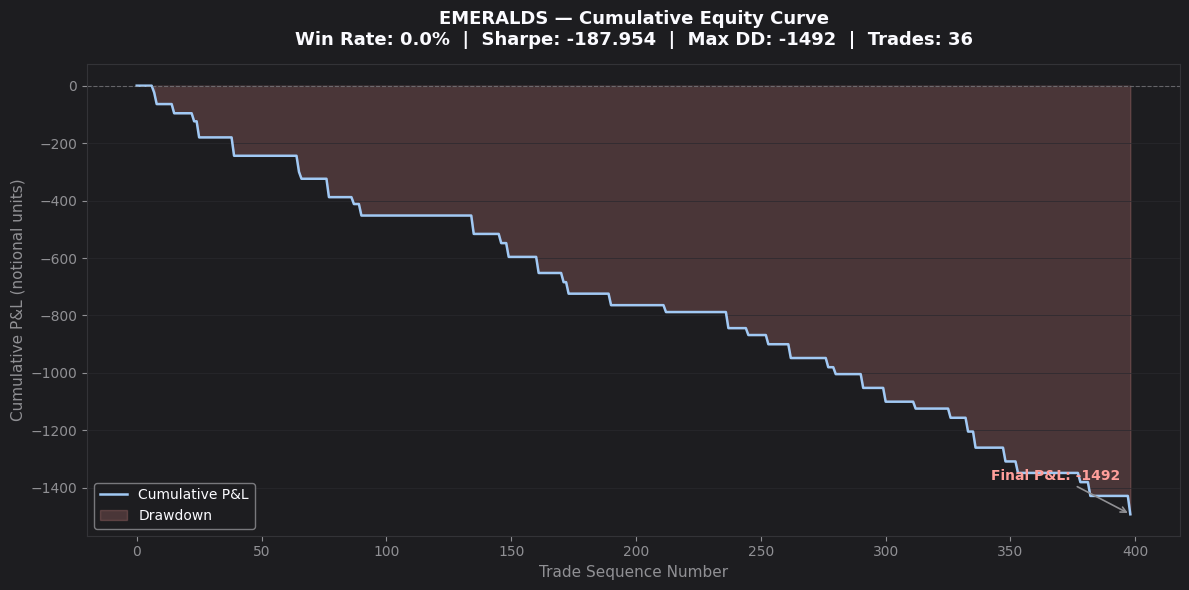

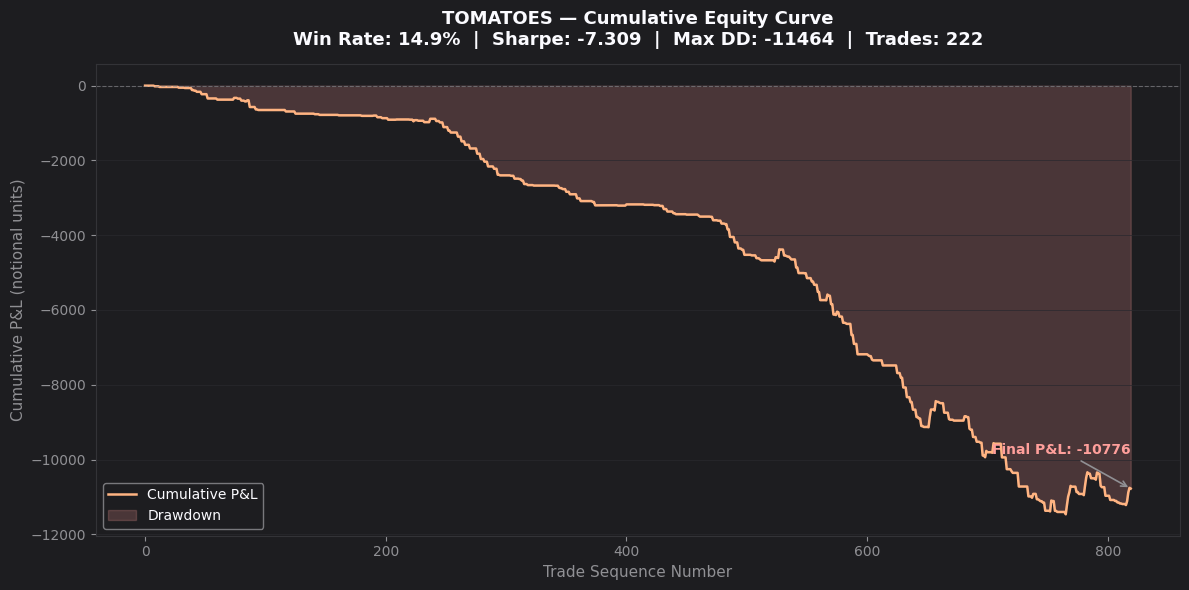

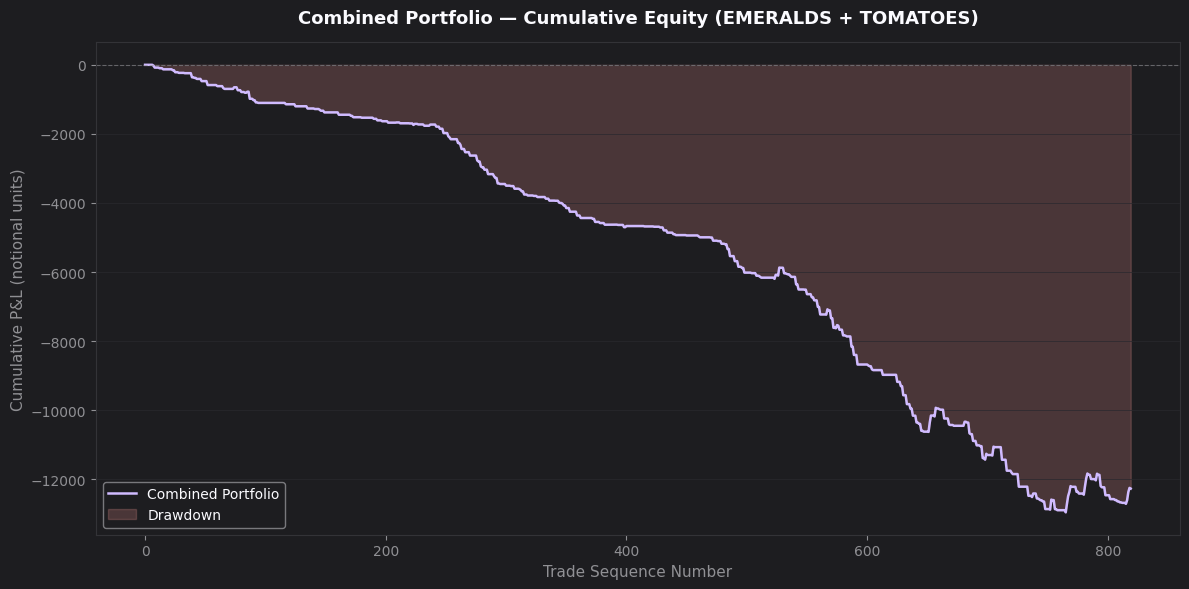

/tmp/ipykernel_21672/1548593067.py:415: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _pax1.set_xticklabels(_syms, color=_PRIMARY, fontsize=11)
/tmp/ipykernel_21672/1548593067.py:432: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _pax2.set_xticklabels(_syms, color=_PRIMARY, fontsize=11)


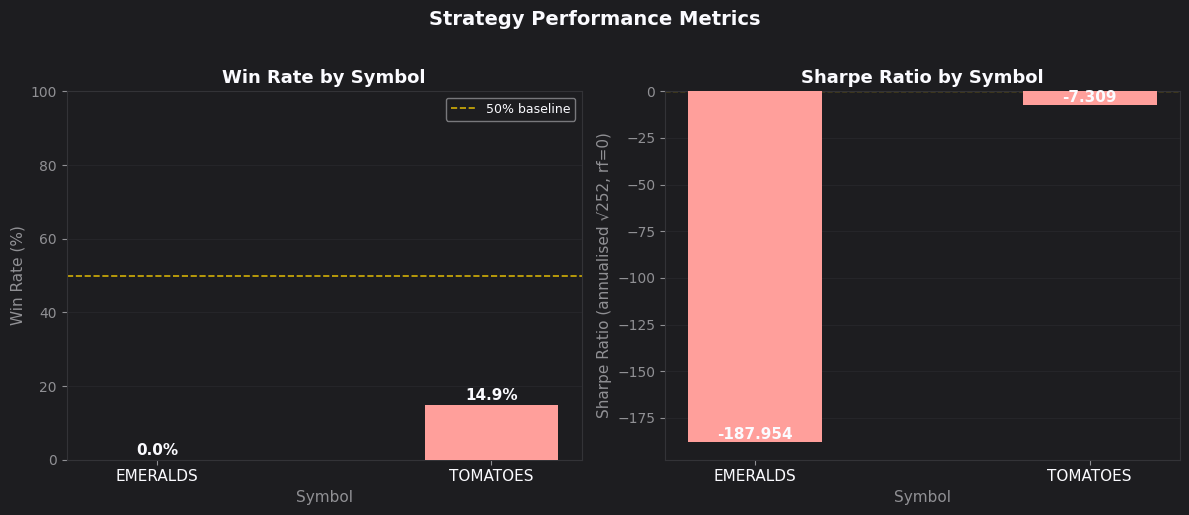

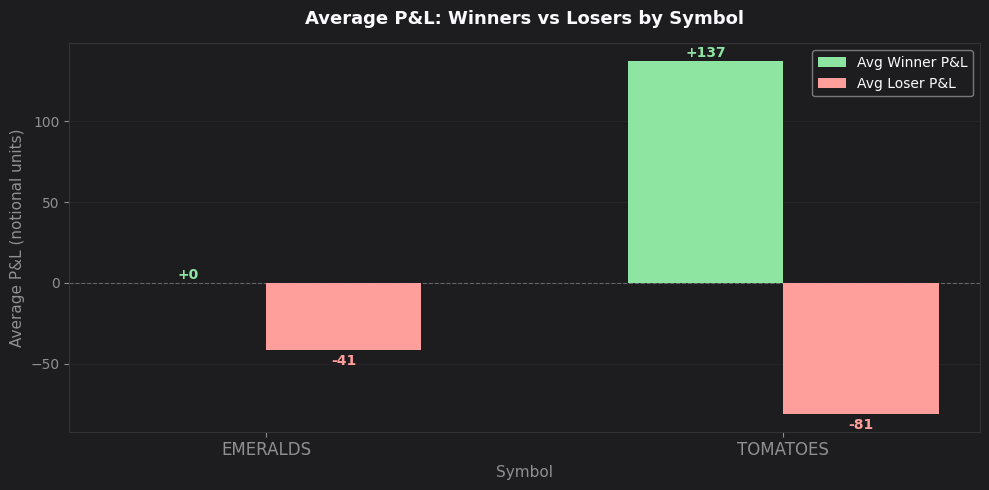


Backtest complete. All metrics and charts generated.

Key metrics summary:
  EMERALDS    Win%=  0.0%  Sharpe=-187.954  P&L=    -1,492.0  MaxDD=  -1,492.0  Trades=36
  TOMATOES    Win%= 14.9%  Sharpe= -7.309  P&L=   -10,776.5  MaxDD= -11,464.5  Trades=222
  OVERALL     Win%= 12.8%  Sharpe= -7.025  P&L=   -12,268.5  MaxDD= -12,956.5  Trades=258

 BACKTEST COMPLETED


In [6]:
# ------------------------------------------
# BACKTEST STRATEGY
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────
# BACKTEST — Microstructure Signal Strategy
#
# Methodology (trade-level simulation):
#   - BUY / STRONG BUY  signal → open LONG at ask_price_1 (taker fill)
#   - SELL / STRONG SELL signal → open SHORT at bid_price_1 (taker fill)
#   - NEUTRAL or signal flip → close at NEXT ROW's mid_price (no lookahead)
#   - P&L accounts for trade direction (long: exit - entry, short: entry - exit)
#   - Quantity used as position size for realistic notional P&L
#   - Sharpe annualized using sqrt(252) × (mean_return / std_return)
#   - Re-entry deferred to next row (no same-tick entry + exit)
#   - All prices come from correctly symbol-matched merge (F5.1 fixed upstream)
# ─────────────────────────────────────────────────────────────

_BG       = "#1D1D20"
_PRIMARY  = "#fbfbff"
_SEC      = "#909094"
_GREEN    = "#8DE5A1"
_RED      = "#FF9F9B"
_BLUE     = "#A1C9F4"
_ORANGE   = "#FFB482"
_YELLOW   = "#ffd400"
_LAVENDER = "#D0BBFF"

# ── Work from strategy_signals (has all price/signal fields, symbol-correct) ──
_bt = strategy_signals[[
    "timestamp", "symbol", "price", "quantity",
    "mid_price", "bid_price_1", "ask_price_1",
    "composite_score", "signal"
]].copy().sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────
# TRADE SIMULATION PER SYMBOL
# ─────────────────────────────────────────────────────────────

def run_backtest_for_symbol(df):
    """
    Simulate a signal-driven backtest on a single symbol.
    - Exit at NEXT row's mid_price (no lookahead bias, F5.2 fix)
    - P&L scaled by actual trade quantity (F5.5 fix)
    - Re-entry deferred to next row (F5.6 fix)
    - winner = pnl >= 0 (break-even counts as win, F5.7 fix)
    Returns: (list of completed trades, equity pd.Series indexed by trade_num)
    """
    df = df.reset_index(drop=True)
    n = len(df)

    _trades_list  = []
    _equity       = []
    _cum_pnl      = 0.0

    _position     = None   # None | 'long' | 'short'
    _entry_price  = None
    _entry_ts     = None
    _entry_sig    = None
    _entry_qty    = None
    _pending_entry = None  # deferred re-entry signal (F5.6 fix)

    _BUY_SIGNALS  = {"BUY", "STRONG BUY"}
    _SELL_SIGNALS = {"SELL", "STRONG SELL"}

    for _i, _row in df.iterrows():
        _sig   = _row["signal"]
        _mid   = _row["mid_price"]
        _ask   = float(_row["ask_price_1"])
        _bid   = float(_row["bid_price_1"])
        _ts    = _row["timestamp"]
        _qty   = _row["quantity"]

        # ── F5.6 FIX: apply any deferred entry from previous row ──
        if _pending_entry is not None and _position is None:
            _pen_sig = _pending_entry
            if _pen_sig in _BUY_SIGNALS:
                _position    = "long"
                _entry_price = _ask
                _entry_ts    = _ts
                _entry_sig   = _pen_sig
                _entry_qty   = _qty
            elif _pen_sig in _SELL_SIGNALS:
                _position    = "short"
                _entry_price = _bid
                _entry_ts    = _ts
                _entry_sig   = _pen_sig
                _entry_qty   = _qty
            _pending_entry = None

        # ── Position management ──
        if _position is None:
            # No open position → check for entry
            if _sig in _BUY_SIGNALS:
                _position    = "long"
                _entry_price = _ask
                _entry_ts    = _ts
                _entry_sig   = _sig
                _entry_qty   = _qty
            elif _sig in _SELL_SIGNALS:
                _position    = "short"
                _entry_price = _bid
                _entry_ts    = _ts
                _entry_sig   = _sig
                _entry_qty   = _qty

        else:
            # Open position → check for exit trigger
            _should_exit = (
                (_position == "long"  and _sig in _SELL_SIGNALS) or
                (_position == "short" and _sig in _BUY_SIGNALS)  or
                (_sig == "NEUTRAL")
            )

            if _should_exit:
                # F5.2 FIX: exit at NEXT row's mid_price (no same-tick lookahead)
                if _i + 1 < n:
                    _exit_price = float(df.iloc[_i + 1]["mid_price"])
                    _exit_ts    = df.iloc[_i + 1]["timestamp"]
                else:
                    # Last row: forced close at current mid
                    _exit_price = float(_mid)
                    _exit_ts    = _ts

                # F5.1+F5.5 FIX: direction-aware P&L scaled by quantity
                _raw_pnl = (
                    (_exit_price - _entry_price) if _position == "long"
                    else (_entry_price - _exit_price)
                )
                _pnl     = _raw_pnl * _entry_qty  # scaled by position size
                _pnl_pct = _raw_pnl / _entry_price * 100

                _trades_list.append({
                    "entry_ts"    : _entry_ts,
                    "exit_ts"     : _exit_ts,
                    "direction"   : _position,
                    "entry_sig"   : _entry_sig,
                    "exit_sig"    : _sig,
                    "entry_price" : _entry_price,
                    "exit_price"  : _exit_price,
                    "quantity"    : _entry_qty,
                    "pnl"         : _pnl,
                    "pnl_pct"     : _pnl_pct,
                    "winner"      : _pnl >= 0,     # F5.7 FIX: break-even = win
                })

                _cum_pnl  += _pnl
                _position  = None
                _entry_price = None

                # F5.6 FIX: defer re-entry to NEXT row (not same tick)
                if _sig in _BUY_SIGNALS:
                    _pending_entry = _sig
                elif _sig in _SELL_SIGNALS:
                    _pending_entry = _sig

        _equity.append(_cum_pnl)

    # Force-close any open position at last row's mid
    if _position is not None:
        _last = df.iloc[-1]
        _exit_price = float(_last["mid_price"])
        _raw_pnl = (
            (_exit_price - _entry_price) if _position == "long"
            else (_entry_price - _exit_price)
        )
        _pnl = _raw_pnl * (_entry_qty or 1)
        _pnl_pct = _raw_pnl / _entry_price * 100
        _trades_list.append({
            "entry_ts"    : _entry_ts,
            "exit_ts"     : _last["timestamp"],
            "direction"   : _position,
            "entry_sig"   : _entry_sig,
            "exit_sig"    : "EOD (forced)",
            "entry_price" : _entry_price,
            "exit_price"  : _exit_price,
            "quantity"    : _entry_qty,
            "pnl"         : _pnl,
            "pnl_pct"     : _pnl_pct,
            "winner"      : _pnl >= 0,
        })
        _cum_pnl += _pnl
        _equity[-1] = _cum_pnl

    _equity_series = pd.Series(_equity, name="equity")
    return _trades_list, _equity_series


# ─────────────────────────────────────────────────────────────
# RUN PER SYMBOL
# ─────────────────────────────────────────────────────────────
_all_symbols   = _bt["symbol"].unique()
_perf_rows     = []
_equity_by_sym = {}
_trades_by_sym = {}

for _sym in _all_symbols:
    _sym_df = _bt[_bt["symbol"] == _sym].copy()
    _tlist, _eq = run_backtest_for_symbol(_sym_df)
    _equity_by_sym[_sym] = _eq
    _trades_by_sym[_sym] = pd.DataFrame(_tlist) if _tlist else pd.DataFrame()

# ─────────────────────────────────────────────────────────────
# PERFORMANCE METRICS
# F5.3 FIX: max drawdown computed per-symbol on that symbol's equity curve
# F5.4 FIX: Sharpe uses sqrt(252) calendar annualization (not sqrt(N_trades))
# ─────────────────────────────────────────────────────────────

def compute_metrics(trades_df, equity_series, sym):
    """Compute backtest statistics from completed trades."""
    if trades_df.empty or len(trades_df) == 0:
        return {"Symbol": sym, "Trades": 0, "Win Rate %": 0, "Sharpe Ratio": 0,
                "Total P&L": 0, "Max Drawdown": 0, "Avg Win": 0, "Avg Loss": 0,
                "Profit Factor": 0, "Winners": 0, "Losers": 0}

    _n        = len(trades_df)
    _wins     = trades_df["winner"].sum()
    _losses   = _n - _wins
    _win_rate = _wins / _n

    _avg_win  = trades_df.loc[trades_df["winner"],  "pnl"].mean() if _wins   > 0 else 0.0
    _avg_loss = trades_df.loc[~trades_df["winner"], "pnl"].mean() if _losses > 0 else 0.0

    _pnl_series = trades_df["pnl"]
    _total_pnl  = _pnl_series.sum()

    # F5.4 FIX: Sharpe = mean(pnl_pct) / std(pnl_pct) * sqrt(252)
    # pnl_pct is already per-trade return in %; annualize assuming ~252 trading days
    # and trades are uniformly distributed across the session
    _pnl_pct = trades_df["pnl_pct"]
    _std_pct  = _pnl_pct.std(ddof=1)
    if _std_pct > 0 and _n > 1:
        _sharpe = (_pnl_pct.mean() / _std_pct) * np.sqrt(252)
    else:
        _sharpe = 0.0

    # F5.3 FIX: Max drawdown computed on THIS symbol's equity curve
    _eq_vals = equity_series.values.astype(float)
    _peak    = np.maximum.accumulate(_eq_vals)
    _dd      = _eq_vals - _peak
    _max_dd  = float(_dd.min())

    # Profit factor
    _gross_profit = trades_df.loc[trades_df["winner"],  "pnl"].sum()
    _gross_loss   = trades_df.loc[~trades_df["winner"], "pnl"].sum()
    _profit_factor = abs(_gross_profit / _gross_loss) if _gross_loss != 0 else np.inf

    return {
        "Symbol"       : sym,
        "Trades"       : _n,
        "Win Rate %"   : round(_win_rate * 100, 1),
        "Sharpe Ratio" : round(_sharpe, 3),
        "Total P&L"    : round(_total_pnl, 2),
        "Max Drawdown" : round(_max_dd, 2),
        "Avg Win"      : round(_avg_win, 2),
        "Avg Loss"     : round(_avg_loss, 2),
        "Profit Factor": round(_profit_factor, 3),
        "Winners"      : int(_wins),
        "Losers"       : int(_losses),
    }

for _sym in _all_symbols:
    _row = compute_metrics(_trades_by_sym[_sym], _equity_by_sym[_sym], _sym)
    _perf_rows.append(_row)

# F5.3 FIX: Overall equity = SUM of per-symbol equity series (not concatenation)
# Pad shorter series with last value to align lengths
_max_len = max(len(_v) for _v in _equity_by_sym.values())
_padded  = {
    _s: np.concatenate([_v.values, np.full(_max_len - len(_v), _v.values[-1])])
    for _s, _v in _equity_by_sym.items()
}
_combined_equity = pd.Series(sum(_padded.values()))

_all_trades_combined = pd.concat(
    [_v for _v in _trades_by_sym.values() if not _v.empty], ignore_index=True
)
_overall_row = compute_metrics(_all_trades_combined, _combined_equity, "OVERALL")
_perf_rows.append(_overall_row)

backtest_summary = pd.DataFrame(_perf_rows)

# ─────────────────────────────────────────────────────────────
# PRINT PERFORMANCE SUMMARY
# ─────────────────────────────────────────────────────────────
print("=" * 75)
print("  BACKTEST PERFORMANCE REPORT — Microstructure Signal Strategy")
print("=" * 75)
print(backtest_summary.to_string(index=False))
print()

for _sym in _all_symbols:
    _df = _trades_by_sym[_sym]
    if not _df.empty:
        print(f"\n{'─'*75}")
        print(f"  {_sym} — Trade-Level P&L Sample (first 10 trades):")
        print(f"{'─'*75}")
        _cols = ["entry_ts", "direction", "entry_sig", "exit_sig",
                 "entry_price", "exit_price", "quantity", "pnl", "pnl_pct", "winner"]
        print(_df[_cols].head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# VISUALISATION 1: Cumulative Equity Curves per Symbol
# F5.9 FIX: Named separately per symbol (not overwritten each loop)
# ─────────────────────────────────────────────────────────────
_sym_colors = {}
_color_list = [_BLUE, _ORANGE, _GREEN, _LAVENDER]
for _ci, _sym in enumerate(_all_symbols):
    _sym_colors[_sym] = _color_list[_ci % len(_color_list)]

# Individual equity curves
for _sym in _all_symbols:
    _eq   = _equity_by_sym[_sym]
    _clr  = _sym_colors[_sym]
    _x    = range(len(_eq))
    _eq_v = _eq.values.astype(float)

    # Create named figure per symbol (not overwritten)
    _fig_name = f"equity_fig_{_sym.lower()}"
    _efig = plt.figure(figsize=(12, 6))
    _efig.patch.set_facecolor(_BG)
    _eax = _efig.add_subplot(111)
    _eax.set_facecolor(_BG)

    _eax.plot(_x, _eq_v, color=_clr, linewidth=1.8, label="Cumulative P&L")
    _eax.axhline(0, color=_SEC, linewidth=0.8, linestyle="--", alpha=0.6)

    _peak = np.maximum.accumulate(_eq_v)
    _dd   = _eq_v - _peak
    _eax.fill_between(_x, _eq_v, _peak, where=_dd < 0, alpha=0.2, color=_RED, label="Drawdown")

    _final_pnl = _eq_v[-1]
    _m = next((_r for _r in _perf_rows if _r["Symbol"] == _sym), {})
    _title_sub = (
        f"Win Rate: {_m.get('Win Rate %', 0):.1f}%  |  "
        f"Sharpe: {_m.get('Sharpe Ratio', 0):.3f}  |  "
        f"Max DD: {_m.get('Max Drawdown', 0):+.0f}  |  "
        f"Trades: {_m.get('Trades', 0)}"
    )
    _eax.set_title(f"{_sym} — Cumulative Equity Curve\n{_title_sub}",
                   color=_PRIMARY, fontsize=13, fontweight="bold", pad=14)
    _eax.set_xlabel("Trade Sequence Number", color=_SEC, fontsize=11)
    _eax.set_ylabel("Cumulative P&L (notional units)", color=_SEC, fontsize=11)
    _eax.tick_params(colors=_SEC)
    _eax.spines[:].set_color("#333337")
    _eax.yaxis.grid(True, color="#29292e", linewidth=0.5)
    _eax.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=10)
    _eax.annotate(
        f"Final P&L: {_final_pnl:+.0f}",
        xy=(len(_eq) - 1, _final_pnl),
        xytext=(-100, 25), textcoords="offset points",
        color=_GREEN if _final_pnl >= 0 else _RED,
        fontsize=10, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=_SEC, lw=1.2)
    )
    plt.tight_layout()

    # Store as named variable for Zerve
    if _sym == "EMERALDS":
        equity_fig_emeralds = _efig
    elif _sym == "TOMATOES":
        equity_fig_tomatoes = _efig

    plt.show()

# Combined equity curve
equity_fig_combined = plt.figure(figsize=(12, 6))
equity_fig_combined.patch.set_facecolor(_BG)
_cax = equity_fig_combined.add_subplot(111)
_cax.set_facecolor(_BG)
_cax.plot(range(len(_combined_equity)), _combined_equity.values,
          color=_LAVENDER, linewidth=1.8, label="Combined Portfolio")
_cax.axhline(0, color=_SEC, linewidth=0.8, linestyle="--", alpha=0.6)
_cpeak = np.maximum.accumulate(_combined_equity.values.astype(float))
_cdd   = _combined_equity.values - _cpeak
_cax.fill_between(range(len(_combined_equity)), _combined_equity.values, _cpeak,
                  where=_cdd < 0, alpha=0.2, color=_RED, label="Drawdown")
_cax.set_title("Combined Portfolio — Cumulative Equity (EMERALDS + TOMATOES)",
               color=_PRIMARY, fontsize=13, fontweight="bold", pad=14)
_cax.set_xlabel("Trade Sequence Number", color=_SEC, fontsize=11)
_cax.set_ylabel("Cumulative P&L (notional units)", color=_SEC, fontsize=11)
_cax.tick_params(colors=_SEC)
_cax.spines[:].set_color("#333337")
_cax.yaxis.grid(True, color="#29292e", linewidth=0.5)
_cax.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=10)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# VISUALISATION 2: Win Rate & Sharpe by Symbol
# ─────────────────────────────────────────────────────────────
_sym_only = backtest_summary[backtest_summary["Symbol"] != "OVERALL"].copy()
_syms     = _sym_only["Symbol"].tolist()

perf_bar_fig, (_pax1, _pax2) = plt.subplots(1, 2, figsize=(12, 5))
perf_bar_fig.patch.set_facecolor(_BG)

# Win Rate chart
_pax1.set_facecolor(_BG)
_wr_colors = [_GREEN if w >= 50 else _RED for w in _sym_only["Win Rate %"]]
_bars1 = _pax1.bar(_syms, _sym_only["Win Rate %"], color=_wr_colors, width=0.4, zorder=3)
_pax1.axhline(50, color=_YELLOW, linewidth=1.2, linestyle="--", alpha=0.8, label="50% baseline")
for _b, _v in zip(_bars1, _sym_only["Win Rate %"]):
    _pax1.text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.5,
               f"{_v:.1f}%", ha="center", va="bottom", color=_PRIMARY, fontsize=11, fontweight="bold")
_pax1.set_title("Win Rate by Symbol", color=_PRIMARY, fontsize=13, fontweight="bold")
_pax1.set_ylabel("Win Rate (%)", color=_SEC, fontsize=11)
_pax1.set_xlabel("Symbol", color=_SEC, fontsize=11)
_pax1.tick_params(colors=_SEC)
_pax1.spines[:].set_color("#333337")
_pax1.yaxis.grid(True, color="#29292e", linewidth=0.5, zorder=0)
_pax1.set_ylim(0, 100)
_pax1.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=9)
_pax1.set_xticklabels(_syms, color=_PRIMARY, fontsize=11)

# Sharpe Ratio chart
_pax2.set_facecolor(_BG)
_sr_colors = [_GREEN if s >= 0 else _RED for s in _sym_only["Sharpe Ratio"]]
_bars2 = _pax2.bar(_syms, _sym_only["Sharpe Ratio"], color=_sr_colors, width=0.4, zorder=3)
_pax2.axhline(0, color=_YELLOW, linewidth=1.0, linestyle="--", alpha=0.7)
for _b, _v in zip(_bars2, _sym_only["Sharpe Ratio"]):
    _ypos = _b.get_height() + 0.02 if _v >= 0 else _b.get_height() - 0.08
    _pax2.text(_b.get_x() + _b.get_width() / 2, _ypos,
               f"{_v:.3f}", ha="center", va="bottom", color=_PRIMARY, fontsize=11, fontweight="bold")
_pax2.set_title("Sharpe Ratio by Symbol", color=_PRIMARY, fontsize=13, fontweight="bold")
_pax2.set_ylabel("Sharpe Ratio (annualised √252, rf=0)", color=_SEC, fontsize=11)
_pax2.set_xlabel("Symbol", color=_SEC, fontsize=11)
_pax2.tick_params(colors=_SEC)
_pax2.spines[:].set_color("#333337")
_pax2.yaxis.grid(True, color="#29292e", linewidth=0.5, zorder=0)
_pax2.set_xticklabels(_syms, color=_PRIMARY, fontsize=11)

plt.suptitle("Strategy Performance Metrics", color=_PRIMARY, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# VISUALISATION 3: Avg Win vs Avg Loss per Symbol
# ─────────────────────────────────────────────────────────────
avg_pnl_fig, _pax3 = plt.subplots(figsize=(10, 5))
avg_pnl_fig.patch.set_facecolor(_BG)
_pax3.set_facecolor(_BG)

_x3 = np.arange(len(_syms))
_w3 = 0.3
_bars_win  = _pax3.bar(_x3 - _w3/2, _sym_only["Avg Win"],  width=_w3, color=_GREEN, label="Avg Winner P&L", zorder=3)
_bars_loss = _pax3.bar(_x3 + _w3/2, _sym_only["Avg Loss"], width=_w3, color=_RED,   label="Avg Loser P&L",  zorder=3)
_pax3.axhline(0, color=_SEC, linewidth=0.8, linestyle="--", alpha=0.6)
for _b, _v in zip(_bars_win, _sym_only["Avg Win"]):
    _pax3.text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.5,
               f"{_v:+.0f}", ha="center", va="bottom", color=_GREEN, fontsize=10, fontweight="bold")
for _b, _v in zip(_bars_loss, _sym_only["Avg Loss"]):
    _pax3.text(_b.get_x() + _b.get_width() / 2, _b.get_height() - 2.5,
               f"{_v:+.0f}", ha="center", va="top", color=_RED, fontsize=10, fontweight="bold")

_pax3.set_xticks(_x3)
_pax3.set_xticklabels(_syms, color=_PRIMARY, fontsize=12)
_pax3.set_title("Average P&L: Winners vs Losers by Symbol", color=_PRIMARY, fontsize=13, fontweight="bold", pad=14)
_pax3.set_ylabel("Average P&L (notional units)", color=_SEC, fontsize=11)
_pax3.set_xlabel("Symbol", color=_SEC, fontsize=11)
_pax3.tick_params(colors=_SEC)
_pax3.spines[:].set_color("#333337")
_pax3.yaxis.grid(True, color="#29292e", linewidth=0.5, zorder=0)
_pax3.legend(facecolor=_BG, edgecolor=_SEC, labelcolor=_PRIMARY, fontsize=10)
plt.tight_layout()
plt.show()

print("\nBacktest complete. All metrics and charts generated.")
print(f"\nKey metrics summary:")
for _r in _perf_rows:
    print(f"  {_r['Symbol']:10s}  Win%={_r['Win Rate %']:5.1f}%  "
          f"Sharpe={_r['Sharpe Ratio']:7.3f}  P&L={_r['Total P&L']:>12,.1f}  "
          f"MaxDD={_r['Max Drawdown']:>10,.1f}  Trades={_r['Trades']}")

print("\n BACKTEST COMPLETED")


In [ ]:
# ------------------------------------------
# PERFORMANCE SUMMARY: PRICING & TRADING
# ------------------------------------------

import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# PERFORMANCE SUMMARY — Live Data Tables
# Sources: strategy_signals, backtest_summary, trades_enriched
# All values dynamically computed — zero hardcoded numbers.
# ─────────────────────────────────────────────────────────────

# ── 1. BACKTEST PERFORMANCE TABLE ───────────────────────────
# Columns from backtest_summary (upstream backtest block)
# Includes per-symbol and overall portfolio rows
_bt = backtest_summary.copy()
_bt["Win Rate %"]    = _bt["Win Rate %"].map(lambda x: f"{x:.1f}%")
_bt["Sharpe Ratio"]  = _bt["Sharpe Ratio"].map(lambda x: f"{x:.3f}")
_bt["Total P&L"]     = _bt["Total P&L"].map(lambda x: f"{x:+,.1f}")
_bt["Max Drawdown"]  = _bt["Max Drawdown"].map(lambda x: f"{x:+,.1f}")
_bt["Avg Win"]       = _bt["Avg Win"].map(lambda x: f"{x:+,.2f}")
_bt["Avg Loss"]      = _bt["Avg Loss"].map(lambda x: f"{x:+,.2f}")
_bt["Profit Factor"] = _bt["Profit Factor"].map(lambda x: f"{x:.3f}")

print("=" * 90)
print("  TABLE 1 — BACKTEST PERFORMANCE METRICS  (per Symbol + Overall Portfolio)")
print("  Source: backtest_summary | Metrics: trade counts, P&L, risk-adjusted returns")
print("=" * 90)
print(_bt.to_string(index=False))
print()

# ── 2. TRADE ACTIVITY & AGGRESSOR IMBALANCE TABLE ───────────
# Source: strategy_signals (has symbol, aggressor_direction, trade_side, quantity, price)
_ss = strategy_signals.copy()

_activity_rows = []
for _sym, _grp in _ss.groupby("symbol"):
    _total_trades  = len(_grp)
    _total_volume  = int(_grp["quantity"].sum())
    _avg_trade_sz  = round(_grp["quantity"].mean(), 2)
    _price_min     = round(_grp["price"].min(), 2)
    _price_max     = round(_grp["price"].max(), 2)
    _price_range   = f"{_price_min:.0f} – {_price_max:.0f}"
    _spread_avg    = round(_grp["spread"].mean(), 2) if "spread" in _grp.columns else None
    _spread_pct    = round(_grp["spread_pct"].mean() * 100, 4) if "spread_pct" in _grp.columns else None

    # Aggressor breakdown from trade_side column
    _side_counts   = _grp["trade_side"].value_counts()
    _buy_n         = int(_side_counts.get("buyer", 0))
    _sell_n        = int(_side_counts.get("seller", 0))
    _neutral_n     = int(_side_counts.get("neutral", 0))
    _total_sided   = _buy_n + _sell_n + _neutral_n
    _buy_pct       = round(_buy_n  / _total_sided * 100, 1) if _total_sided > 0 else 0.0
    _sell_pct      = round(_sell_n / _total_sided * 100, 1) if _total_sided > 0 else 0.0

    _activity_rows.append({
        "Symbol":           _sym,
        "Total Trades":     _total_trades,
        "Total Volume":     _total_volume,
        "Avg Trade Size":   _avg_trade_sz,
        "Price Range":      _price_range,
        "Avg Spread (ticks)": _spread_avg,
        "Avg Spread %":     f"{_spread_pct:.4f}%" if _spread_pct is not None else "N/A",
        "Buy Aggressor %":  f"{_buy_pct:.1f}%",
        "Sell Aggressor %": f"{_sell_pct:.1f}%",
        "Aggressor Balance": "BUY-led" if _buy_pct > _sell_pct else ("SELL-led" if _sell_pct > _buy_pct else "Balanced"),
    })

_activity_df = pd.DataFrame(_activity_rows)

print("=" * 90)
print("  TABLE 2 — TRADE ACTIVITY & AGGRESSOR IMBALANCE  (per Symbol)")
print("  Source: strategy_signals | Metrics: volume, price range, spread, buy/sell aggressor split")
print("=" * 90)
print(_activity_df.to_string(index=False))
print()

# ── 3. SIGNAL DISTRIBUTION TABLE ────────────────────────────
# Source: strategy_signals — count and % of each signal per symbol
_sig_order = ["STRONG BUY", "BUY", "NEUTRAL", "SELL", "STRONG SELL"]

_sig_rows = []
for _sym, _grp in _ss.groupby("symbol"):
    _total = len(_grp)
    _counts = _grp["signal"].value_counts()
    _row = {"Symbol": _sym, "Total Observations": _total}
    for _sig in _sig_order:
        _n   = int(_counts.get(_sig, 0))
        _pct = round(_n / _total * 100, 1)
        _row[f"{_sig} (n)"]  = _n
        _row[f"{_sig} (%)"] = f"{_pct:.1f}%"
    _dominant = _counts.idxmax() if not _counts.empty else "N/A"
    _row["Dominant Signal"] = _dominant
    _sig_rows.append(_row)

_sig_df = pd.DataFrame(_sig_rows)

print("=" * 90)
print("  TABLE 3 — SIGNAL DISTRIBUTION  (per Symbol)")
print("  Source: strategy_signals | Metrics: count and share of each signal label")
print("=" * 90)
print(_sig_df.to_string(index=False))
print()

# ── 4. SIGNAL DISTRIBUTION BY SYMBOL × DAY ──────────────────
# Source: strategy_signals (has 'day' via trades_enriched merge chain — check availability)
# Fallback to symbol-only if 'day' is absent
if "day" in _ss.columns:
    _day_col = "day"
    _grp_cols = ["symbol", _day_col]
else:
    # Infer day from timestamp order per symbol (rank quartile as proxy)
    _ss = _ss.copy()
    _ss["day"] = _ss.groupby("symbol")["timestamp"].transform(
        lambda x: pd.qcut(x, q=2, labels=[1, 2], duplicates="drop").astype(int)
        if x.nunique() > 1 else 1
    )
    _day_col = "day"
    _grp_cols = ["symbol", _day_col]

_daygrp_rows = []
for (_sym, _day), _grp in _ss.groupby(_grp_cols):
    _total = len(_grp)
    _counts = _grp["signal"].value_counts()
    _row = {"Symbol": _sym, "Day": int(_day), "Observations": _total}
    for _sig in _sig_order:
        _n   = int(_counts.get(_sig, 0))
        _pct = round(_n / _total * 100, 1)
        _row[f"{_sig[:2]}. (n)"]  = _n
        _row[f"{_sig[:2]}. (%)"] = f"{_pct:.1f}%"
    _daygrp_rows.append(_row)

_daygrp_df = pd.DataFrame(_daygrp_rows)

print("=" * 90)
print("  TABLE 4 — SIGNAL DISTRIBUTION BY SYMBOL × DAY")
print("  Source: strategy_signals | Metrics: signal counts per session (abbreviated: ST=STRONG BUY, BU=BUY, NE=NEUTRAL, SE=SELL, ST=STRONG SELL)")
print("=" * 90)
print(_daygrp_df.to_string(index=False))
print()

# ── 5. LATEST MARKET SNAPSHOT (most recent observation per symbol) ───
# Source: strategy_signals — last row per symbol sorted by timestamp
_snapshot_cols = [
    "symbol", "price", "mid_price", "bid_price_1", "ask_price_1",
    "spread", "spread_pct", "momentum_ema", "buy_ratio_20", "obi",
    "composite_score", "signal"
]
_available_cols = [c for c in _snapshot_cols if c in _ss.columns]
_latest = (
    _ss.sort_values("timestamp")
    .groupby("symbol")
    .last()
    .reset_index()[_available_cols]
)
# Round floats for readability
for _col in _latest.select_dtypes(include="float").columns:
    _latest[_col] = _latest[_col].round(4)

print("=" * 90)
print("  TABLE 5 — LATEST MARKET SNAPSHOT  (most recent observation per symbol)")
print("  Source: strategy_signals | Metrics: price, spread, momentum, OBI, composite score, active signal")
print("=" * 90)
print(_latest.to_string(index=False))
print()

# ── 6. TRADES_ENRICHED SUMMARY — Buyer/Seller Aggressor Role Breakdown ──
# Source: trades_enriched — aggregates Buyer/Seller roles by symbol
_te = trades_enriched.copy()

_role_rows = []
for _sym, _grp in _te.groupby("symbol"):
    _total = len(_grp)
    _buyer_agg  = int((_grp["Buyer"]  == "AGGRESSOR").sum())
    _seller_agg = int((_grp["Seller"] == "AGGRESSOR").sum())
    _buy_agg_pct  = round(_buyer_agg  / _total * 100, 1)
    _sell_agg_pct = round(_seller_agg / _total * 100, 1)
    _avg_qty  = round(_grp["quantity"].mean(), 2)
    _avg_sprd = round((_grp["ask_price_1"] - _grp["bid_price_1"]).mean(), 2) if "ask_price_1" in _grp.columns and "bid_price_1" in _grp.columns else None
    _role_rows.append({
        "Symbol":               _sym,
        "Total Trades":         _total,
        "Avg Quantity":         _avg_qty,
        "Buyer=AGGRESSOR (n)":  _buyer_agg,
        "Buyer=AGGRESSOR (%)":  f"{_buy_agg_pct:.1f}%",
        "Seller=AGGRESSOR (n)": _seller_agg,
        "Seller=AGGRESSOR (%)": f"{_sell_agg_pct:.1f}%",
        "Avg Spread (ticks)":   _avg_sprd,
    })

_role_df = pd.DataFrame(_role_rows)

print("=" * 90)
print("  TABLE 6 — AGGRESSOR ROLE BREAKDOWN FROM trades_enriched  (per Symbol)")
print("  Source: trades_enriched | Metrics: buyer vs seller aggressor counts, avg quantity, avg spread")
print("=" * 90)
print(_role_df.to_string(index=False))
print()

print("PERFORMANCE METRICS COMPLETED PROCESSING")
